# Week 9 & 10 challenge:
## Build a Pokemon image classifier

### Dataset from Kaggle ["7000 Labeled Pokemon"](https://www.kaggle.com/datasets/lantian773030/pokemonclassification/data)

Add imports

In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model, Sequential, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, GlobalMaxPooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from PIL import Image
import random

Seed the whole file

In [58]:
def seed_everything(seed=57):
    # Seed value for TensorFlow
    tf.random.set_seed(seed)
    
    # Seed value for Python's random library
    random.seed(seed)

    # Seed value for NumPy
    np.random.seed(seed)
    
    
    # Force TensorFlow to use single thread
    # Multiple threads are a potential source of non-reproducible results.
    session_conf = tf.compat.v1.ConfigProto(
        intra_op_parallelism_threads=1,
        inter_op_parallelism_threads=1
    )

    # Make sure that TensorFlow uses a deterministic operation wherever possible
    tf.compat.v1.set_random_seed(seed)

    # Create a TensorFlow session with the default graph and the specified configuration
    session = tf.compat.v1.Session(graph=tf.compat.v1.get_default_graph(), config=session_conf)

    # Set the created session as the default session for Keras
    tf.compat.v1.keras.backend.set_session(session)

# Call the function
seed_everything()

Basic preprocessing of the data

In [59]:
# Directory where your dataset is stored
dataset_directory = 'C:/Users/USER/Desktop/PokemonData'

# ImageDataGenerator for basic preprocessing and loading
train_datagen_v1 = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1  # using 10% of the data for validation due to small dataset
)

# Load images from directory and prepare training dataset
train_generator_v1 = train_datagen_v1.flow_from_directory(
    dataset_directory,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training'  # Set as training data
)

# Load images from directory and prepare validation dataset
validation_generator_v1 = train_datagen_v1.flow_from_directory(
    dataset_directory,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'  # Set as validation data
)

Found 6205 images belonging to 150 classes.
Found 615 images belonging to 150 classes.


Show a couple of images

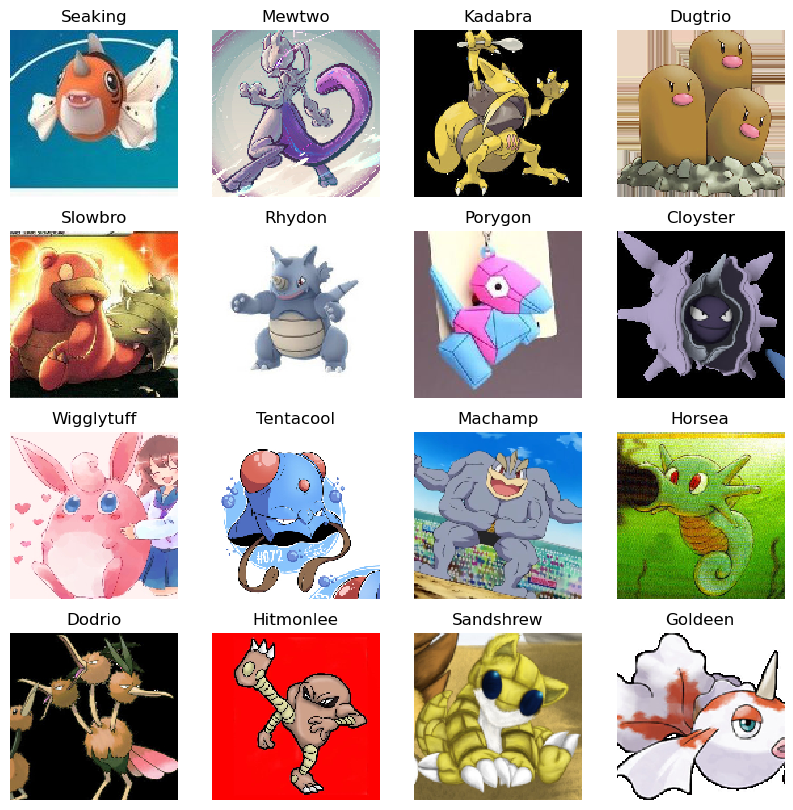

In [60]:
# Show a few examples per class
for images, labels in train_generator_v1:
    plt.figure(figsize=(10,10))
    for i in range(16):
        ax = plt.subplot(4, 4, i+1)
        ax.imshow(images[i], interpolation='nearest')
        ax.set_title(list(train_generator_v1.class_indices.keys())[np.argmax(labels[i])])
        ax.axis('off')
    plt.show()
    break

First model architecture

In [61]:
model_v1 = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(150, activation='softmax')
])

model_v1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model_v1.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_14 (Conv2D)          (None, 126, 126, 32)      896       
                                                                 
 max_pooling2d_14 (MaxPoolin  (None, 63, 63, 32)       0         
 g2D)                                                            
                                                                 
 conv2d_15 (Conv2D)          (None, 61, 61, 64)        18496     
                                                                 
 max_pooling2d_15 (MaxPoolin  (None, 30, 30, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_16 (Conv2D)          (None, 28, 28, 128)       73856     
                                                                 
 max_pooling2d_16 (MaxPoolin  (None, 14, 14, 128)     

Train the first model

In [62]:
early_stopping = EarlyStopping(monitor='val_loss', patience=5, verbose=1)

history_v1 = model_v1.fit(
    train_generator_v1,
    epochs=25,
    validation_data=validation_generator_v1,
    callbacks=[early_stopping]  # Include early stopping here
)

Epoch 1/25
194/194 [==============================] - 23s 117ms/step - loss: 4.6433 - accuracy: 0.0387 - val_loss: 3.6970 - val_accuracy: 0.1382
Epoch 2/25
194/194 [==============================] - 55s 282ms/step - loss: 3.3955 - accuracy: 0.1915 - val_loss: 2.7110 - val_accuracy: 0.3577
Epoch 3/25
194/194 [==============================] - 56s 290ms/step - loss: 2.5409 - accuracy: 0.3616 - val_loss: 2.4100 - val_accuracy: 0.4033
Epoch 4/25
194/194 [==============================] - 57s 294ms/step - loss: 1.9310 - accuracy: 0.4973 - val_loss: 2.0280 - val_accuracy: 0.5106
Epoch 5/25
194/194 [==============================] - 56s 291ms/step - loss: 1.4339 - accuracy: 0.6135 - val_loss: 1.8775 - val_accuracy: 0.5463
Epoch 6/25
194/194 [==============================] - 59s 304ms/step - loss: 1.0596 - accuracy: 0.7017 - val_loss: 1.9078 - val_accuracy: 0.5480
Epoch 7/25
194/194 [==============================] - 58s 297ms/step - loss: 0.7637 - accuracy: 0.7828 - val_loss: 1.9556 - val_ac

Plot the performance

In [63]:
# Plot the model performance
def plot_model_performance(history):
    training_accuracy = history.history['accuracy']
    validation_accuracy = history.history['val_accuracy']
    training_loss = history.history['loss']
    validation_loss = history.history['val_loss']
    epochs_range = range(len(training_accuracy))
    
    plt.figure(figsize=(15, 5))
    
    # Plot training and validation accuracy per epoch
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, training_accuracy, label='Training Accuracy')
    plt.plot(epochs_range, validation_accuracy, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Plot training and validation loss per epoch
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, training_loss, label='Training Loss')
    plt.plot(epochs_range, validation_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

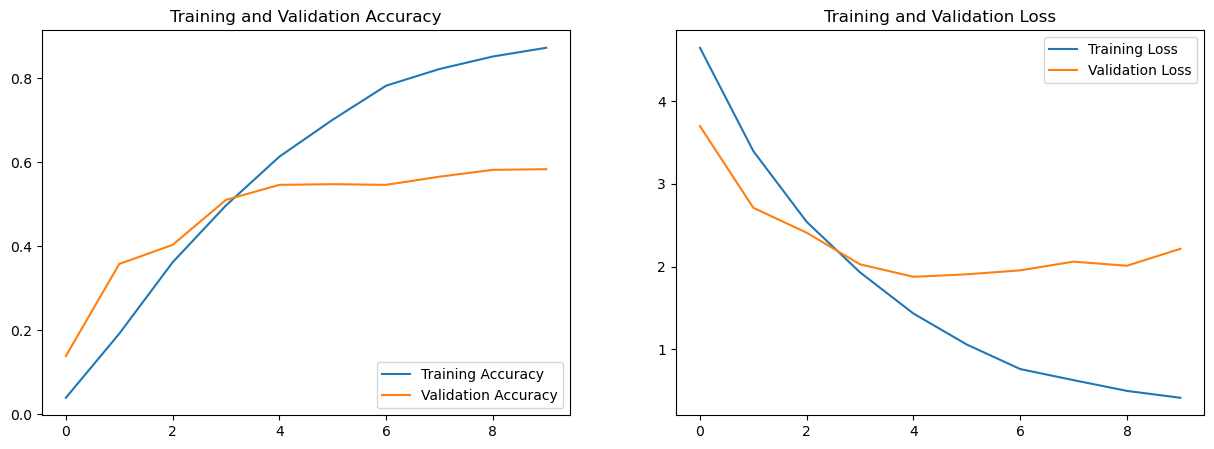

In [64]:
plot_model_performance(history_v1)

# Transfer Learning

Try with transfer learning using MobileNetv2

Same preproccesing as before

In [65]:
# ImageDataGenerator for basic preprocessing and loading
train_datagen_transfer = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.1) # using 10% of the data for validation due to small dataset

# Load images from directory and prepare training dataset
train_generator_transfer = train_datagen_transfer.flow_from_directory(
    dataset_directory,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='training' 
)

# Load images from directory and prepare validation dataset
validation_generator_transfer = train_datagen_transfer.flow_from_directory(
    dataset_directory,
    target_size=(128, 128),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

Found 6205 images belonging to 150 classes.
Found 615 images belonging to 150 classes.


In [66]:
# Initialize MobileNetV2 base model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
base_model.trainable = False

In [69]:
# Create new model on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(150, activation='softmax')(x)

model_transfer = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model_transfer.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [70]:
# First training
history_trasfer = model_transfer.fit(
    train_generator_transfer,
    epochs=10,
    validation_data=validation_generator_transfer
)

Epoch 1/10
194/194 [==============================] - 35s 169ms/step - loss: 5.1490 - accuracy: 0.0197 - val_loss: 4.5739 - val_accuracy: 0.1008
Epoch 2/10
194/194 [==============================] - 59s 305ms/step - loss: 4.3516 - accuracy: 0.1080 - val_loss: 3.9031 - val_accuracy: 0.2813
Epoch 3/10
194/194 [==============================] - 58s 301ms/step - loss: 3.6512 - accuracy: 0.2143 - val_loss: 3.1917 - val_accuracy: 0.4276
Epoch 4/10
194/194 [==============================] - 58s 299ms/step - loss: 2.9501 - accuracy: 0.3515 - val_loss: 2.6236 - val_accuracy: 0.5041
Epoch 5/10
194/194 [==============================] - 61s 314ms/step - loss: 2.4141 - accuracy: 0.4548 - val_loss: 2.2650 - val_accuracy: 0.5528
Epoch 6/10
194/194 [==============================] - 60s 306ms/step - loss: 2.0404 - accuracy: 0.5326 - val_loss: 1.9937 - val_accuracy: 0.6016
Epoch 7/10
194/194 [==============================] - 57s 293ms/step - loss: 1.7392 - accuracy: 0.5918 - val_loss: 1.7996 - val_ac

In [ ]:
base_model.trainable = True
model_transfer.compile(optimizer=Adam(learning_rate=0.00001), loss='categorical_crossentropy', metrics=['accuracy'])
# Fine-tuning from this layer onwards
fine_tune_at = 100
# Freeze all the layers before the `fine_tune_at` layer
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable =  False

In [72]:
# Continue training
history_fine = model_transfer.fit(
    train_generator_transfer,
    epochs=10,
    validation_data=validation_generator_transfer
)

Epoch 1/10
194/194 [==============================] - 28s 122ms/step - loss: 2.7802 - accuracy: 0.3634 - val_loss: 1.3845 - val_accuracy: 0.6943
Epoch 2/10
194/194 [==============================] - 19s 99ms/step - loss: 2.1556 - accuracy: 0.4954 - val_loss: 1.3228 - val_accuracy: 0.6943
Epoch 3/10
194/194 [==============================] - 19s 98ms/step - loss: 1.7861 - accuracy: 0.5797 - val_loss: 1.2362 - val_accuracy: 0.7138
Epoch 4/10
194/194 [==============================] - 20s 101ms/step - loss: 1.5196 - accuracy: 0.6327 - val_loss: 1.1644 - val_accuracy: 0.7350
Epoch 5/10
194/194 [==============================] - 61s 317ms/step - loss: 1.3375 - accuracy: 0.6754 - val_loss: 1.1002 - val_accuracy: 0.7463
Epoch 6/10
194/194 [==============================] - 64s 328ms/step - loss: 1.1685 - accuracy: 0.7172 - val_loss: 1.0318 - val_accuracy: 0.7561
Epoch 7/10
194/194 [==============================] - 62s 319ms/step - loss: 1.0638 - accuracy: 0.7376 - val_loss: 0.9690 - val_accu

In [73]:
# Evaluate model
val_loss, val_acc = model_transfer.evaluate(validation_generator_transfer)
print(f"Validation accuracy after fine-tuning: {val_acc * 100:.2f}%")

20/20 [==============================] - 4s 188ms/step - loss: 0.8364 - accuracy: 0.8146
Validation accuracy after fine-tuning: 81.46%


In [11]:
# Function to get class labels
def get_class_labels(dataset_directory):
    
    class_labels = [d for d in os.listdir(dataset_directory) if os.path.isdir(os.path.join(dataset_directory, d))]
    class_labels.sort()
    return class_labels

dataset_directory = 'C:/Users/USER/Desktop/PokemonData'
class_labels = get_class_labels(dataset_directory)
print("Class labels:", class_labels)
labels = get_class_labels(dataset_directory)

Class labels: ['Abra', 'Aerodactyl', 'Alakazam', 'Alolan Sandslash', 'Arbok', 'Arcanine', 'Articuno', 'Beedrill', 'Bellsprout', 'Blastoise', 'Bulbasaur', 'Butterfree', 'Caterpie', 'Chansey', 'Charizard', 'Charmander', 'Charmeleon', 'Clefable', 'Clefairy', 'Cloyster', 'Cubone', 'Dewgong', 'Diglett', 'Ditto', 'Dodrio', 'Doduo', 'Dragonair', 'Dragonite', 'Dratini', 'Drowzee', 'Dugtrio', 'Eevee', 'Ekans', 'Electabuzz', 'Electrode', 'Exeggcute', 'Exeggutor', 'Farfetchd', 'Fearow', 'Flareon', 'Gastly', 'Gengar', 'Geodude', 'Gloom', 'Golbat', 'Goldeen', 'Golduck', 'Golem', 'Graveler', 'Grimer', 'Growlithe', 'Gyarados', 'Haunter', 'Hitmonchan', 'Hitmonlee', 'Horsea', 'Hypno', 'Ivysaur', 'Jigglypuff', 'Jolteon', 'Jynx', 'Kabuto', 'Kabutops', 'Kadabra', 'Kakuna', 'Kangaskhan', 'Kingler', 'Koffing', 'Krabby', 'Lapras', 'Lickitung', 'Machamp', 'Machoke', 'Machop', 'Magikarp', 'Magmar', 'Magnemite', 'Magneton', 'Mankey', 'Marowak', 'Meowth', 'Metapod', 'Mew', 'Mewtwo', 'Moltres', 'MrMime', 'Muk', '

In [12]:
# Load and preprocess image
def load_and_preprocess_image(image_path, target_size=(128, 128)):
    image = Image.open(image_path)
    image = image.resize(target_size)
    image = np.array(image)
    if image.ndim == 3 and image.shape[2] == 4:  
        image = image[..., :3]
    image = image / 255.0
    return np.expand_dims(image, axis=0)

1/1 [==============================] - 0s 19ms/step


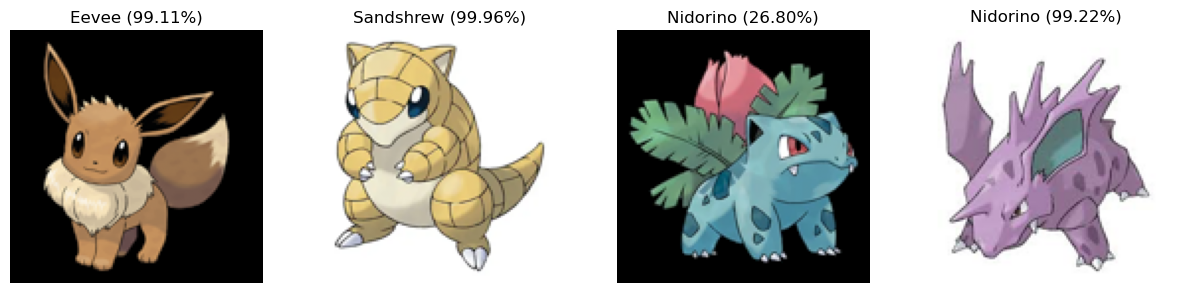

In [13]:
# Function to predict and visualize
def predict_and_visualize(image_paths, model, labels):
    plt.figure(figsize=(15, 5))  
    for i, image_path in enumerate(image_paths):
        img = load_and_preprocess_image(image_path)
        predictions = model.predict(img)
        predicted_class_idx = np.argmax(predictions)
        predicted_class = labels[predicted_class_idx]
        confidence = np.max(predictions) * 100  

        ax = plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(img[0])
        plt.title(f'{predicted_class} ({confidence:.2f}%)')
        plt.axis('off')
    plt.show()

# Define the paths to your images
image_paths = ['eve.png', 'sandshrew.png', 'ivysaur.png', 'nidorino.jpg']  

# Perform predictions and visualize
predict_and_visualize(image_paths, model_transfer, labels)